In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data.csv')

🧠 Section 1: Dataset Understanding

1. What is the total number of rows and columns in the dataset?

2. What are the data types of each feature?

3. Which features are categorical and which are numerical?

4. Are there any missing values? If yes, in which columns?

5. Are there any duplicate records present?

In [4]:
print("Total number of rows and columns in the dataset:", df.shape)

Total number of rows and columns in the dataset: (1705, 11)


In [5]:
print("Data types of each column:\n", df.dtypes)

Data types of each column:
 Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score             float64
Overall_Impact                   object
dtype: object


In [6]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['Student_ID', 'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')
Categorical columns: Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Overall_Impact'],
      dtype='object')


In [7]:
print("missing values in each column:\n", df.isnull().sum())

missing values in each column:
 Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64


In [8]:
print("Duplicated rows in the dataset:", df.duplicated().sum())

Duplicated rows in the dataset: 0


🧹 Section 2: Data Cleaning Validation

6. Are there inconsistent values in categorical columns (e.g., "M", "male", "Male")?

7. Are there any unrealistic or invalid values (e.g., usage > 24 hours)?

8. Are column names properly formatted for analysis?

9. Are numerical columns stored in correct formats?

THE DATA IS CLEAN AND WE'VE ALREADY DONE PRE-PROCESSING IN OTHER IPYNB


Section 3: Univariate Analysis

10. What is the distribution of Avg_Daily_Usage_Hours?

11. What is the distribution of Mental_Health_Score?

12. What is the distribution of Sleep_Hours_Per_Night?

13. Which social media platform is most frequently used?

14. What is the gender distribution in the dataset?

In [10]:
def distribution_plot(column):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

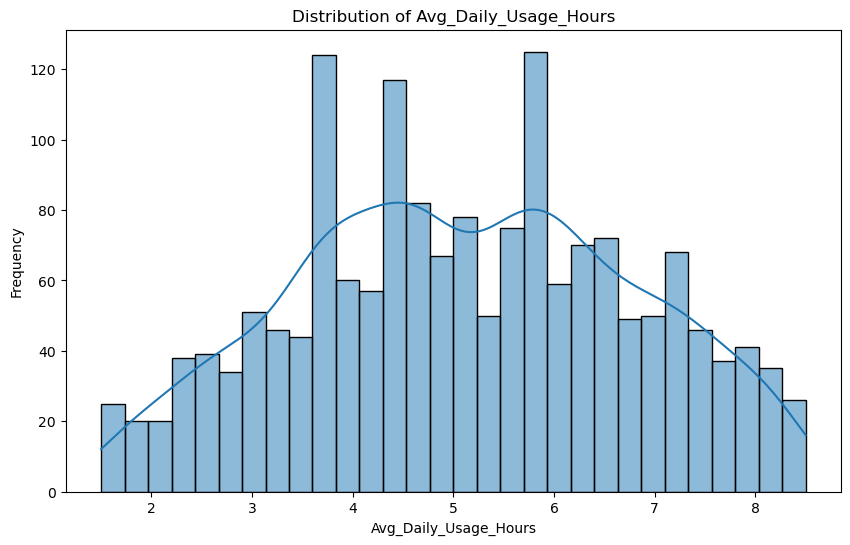

In [11]:
distribution_plot('Avg_Daily_Usage_Hours')

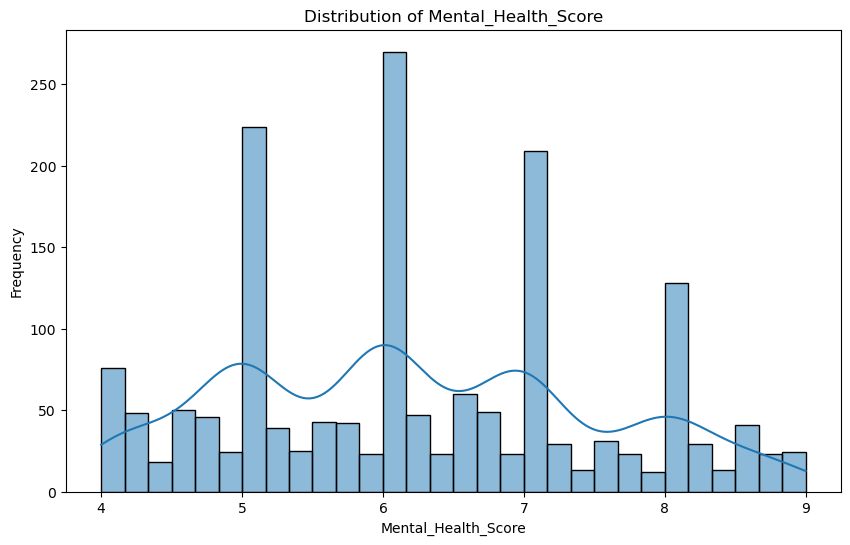

In [12]:
distribution_plot('Mental_Health_Score')

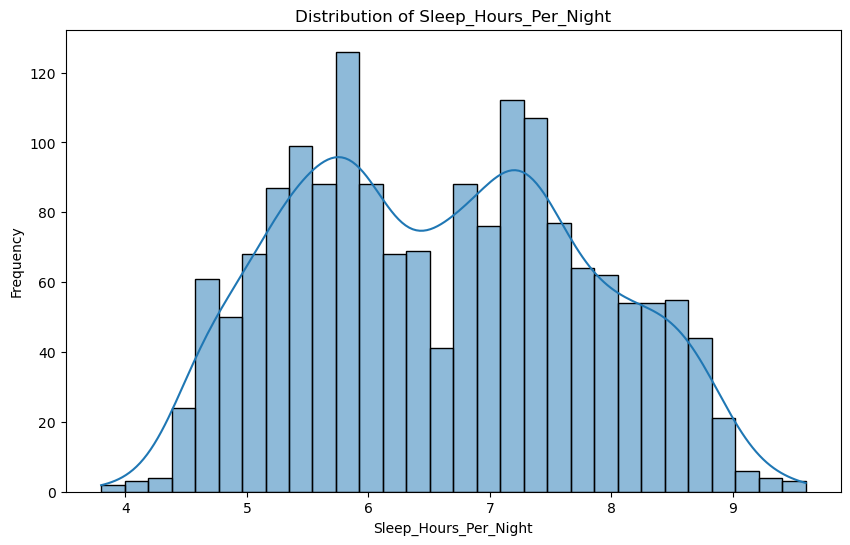

In [13]:
distribution_plot('Sleep_Hours_Per_Night')

## H-1: - Possibility is this that those who spend more time on social media may have less mental score.

In [14]:
## tabe to understand average of each matrix
num_col=df.select_dtypes(include=[np.number]).columns
for i in num_col:
    print(f"Average of {i}: {df[i].mean()}")

Average of Student_ID: 439.51026392961876
Average of Age: 20.84809384164223
Average of Avg_Daily_Usage_Hours: 5.103636363636364
Average of Sleep_Hours_Per_Night: 6.598709677419355
Average of Mental_Health_Score: 6.215131964809384


## H-2:- It is possible that people having less sleep hours per night and higher average daily usage hours of social media have lower mental health scores.

In [19]:
## most used platform
print("Most used platform:", df['Most_Used_Platform'].mode()[0])

Most used platform: Instagram


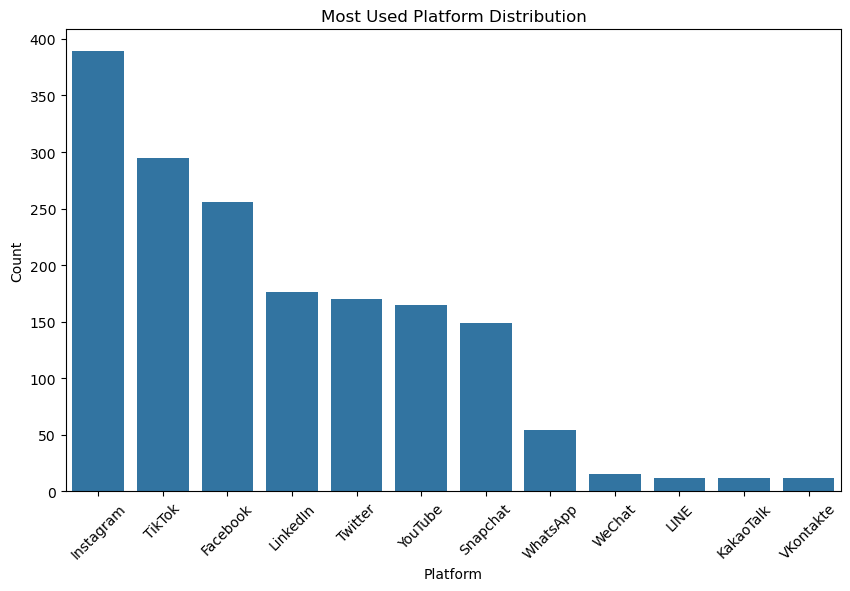

In [21]:
most=df['Most_Used_Platform'].value_counts().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=most['Most_Used_Platform'], y=most['count'])
plt.title('Most Used Platform Distribution')    
plt.xlabel('Platform')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

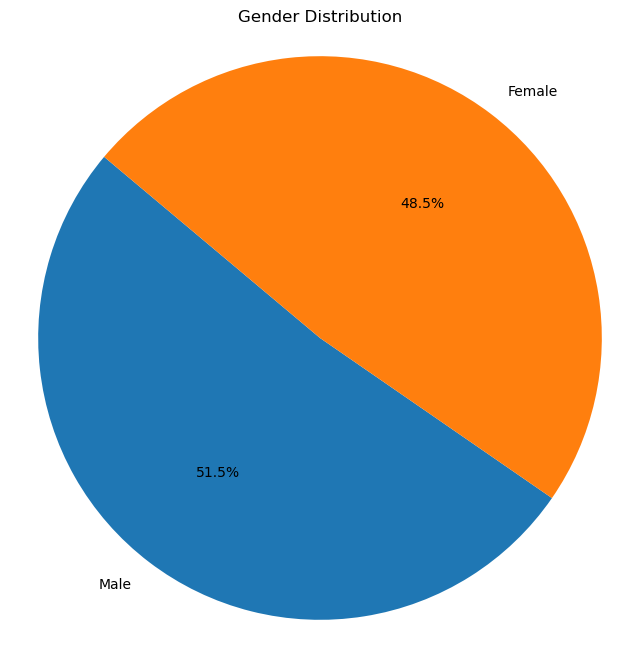

In [25]:
## gender distribution pie chart
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

Section 4: Bivariate Analysis

15. Is there a relationship between social media usage and mental health score?

16. How does social media usage affect sleep duration?

17. Do students who report academic impact have higher usage?

18. Is there any difference in mental health scores across genders?

19. Does age influence social media usage?

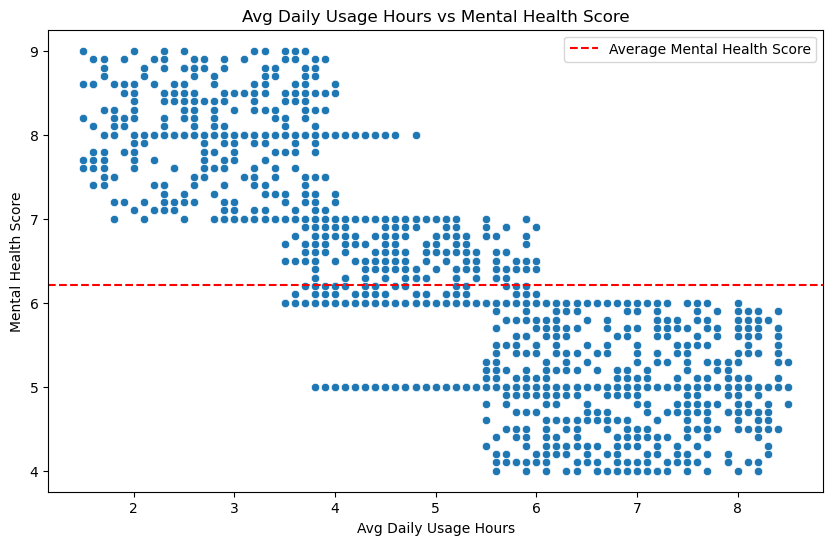

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)
plt.title('Avg Daily Usage Hours vs Mental Health Score')
plt.xlabel('Avg Daily Usage Hours')
plt.ylabel('Mental Health Score')
plt.axhline(y=df['Mental_Health_Score'].mean(), color='r', linestyle='--', label='Average Mental Health Score')
plt.legend()
plt.show()

Their relation between the avg_daily_usage and mental health suggests that those who use social media more have less mental score

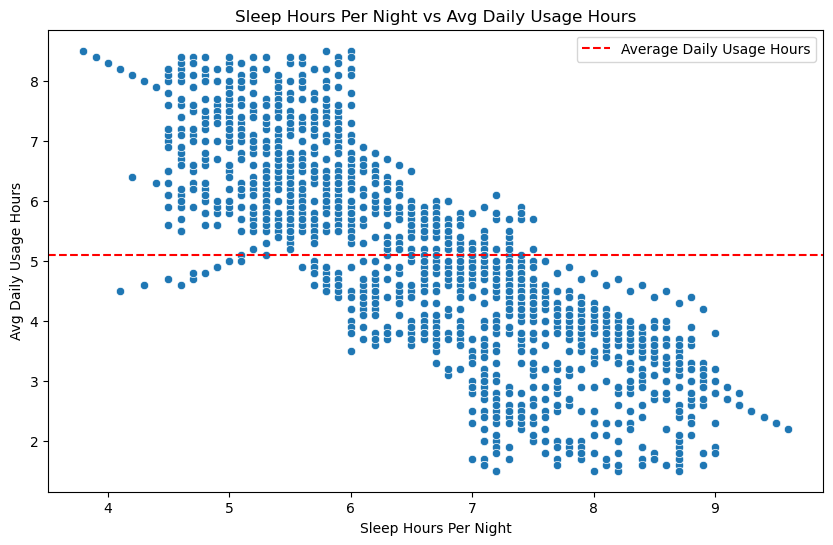

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Avg_Daily_Usage_Hours', data=df)
plt.title('Sleep Hours Per Night vs Avg Daily Usage Hours')
plt.xlabel('Sleep Hours Per Night')
plt.ylabel('Avg Daily Usage Hours')
plt.axhline(y=df['Avg_Daily_Usage_Hours'].mean(), color='r', linestyle='--', label='Average Daily Usage Hours')
plt.legend()
plt.show()

Their is direct relation between avg_daily_usage and sleep hours that thos who use social media more have less sleep hours

In [29]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


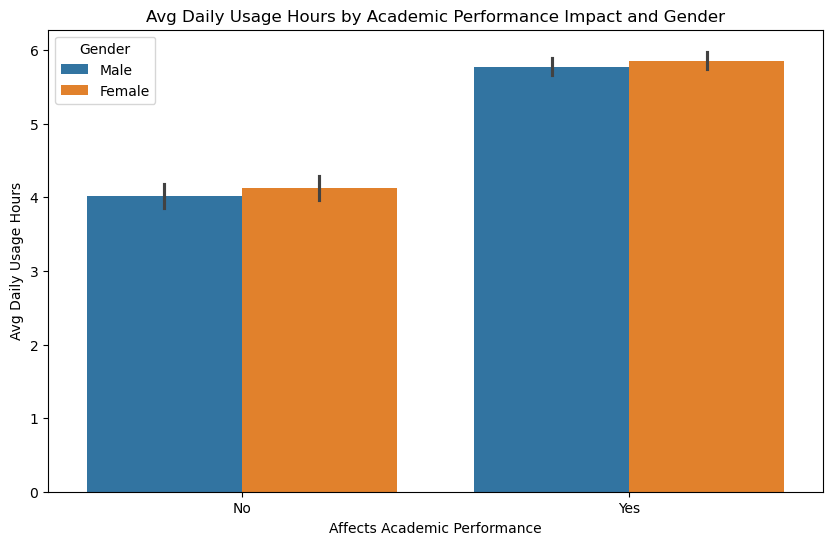

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Affects_Academic_Performance', y='Avg_Daily_Usage_Hours', data=df, hue='Gender')
plt.title('Avg Daily Usage Hours by Academic Performance Impact and Gender')
plt.xlabel('Affects Academic Performance')
plt.ylabel('Avg Daily Usage Hours')
plt.legend(title='Gender')
plt.show()

Text(0, 0.5, 'Mental Health Score')

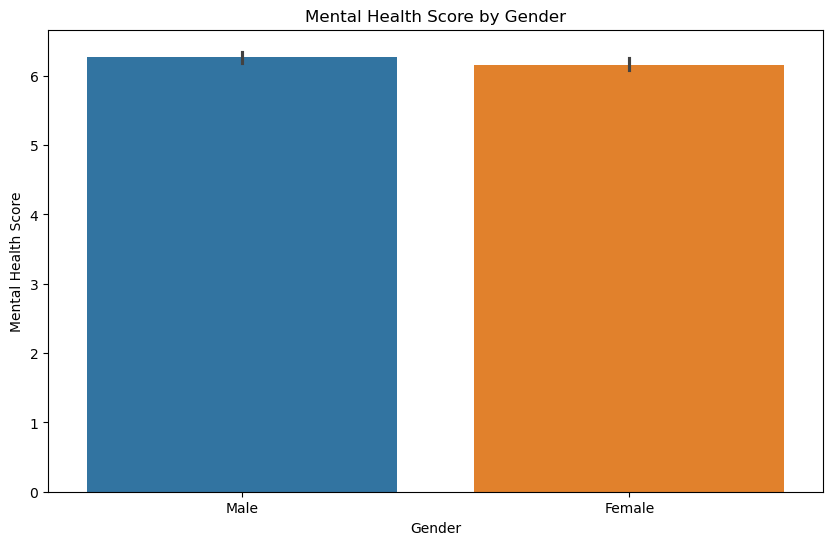

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='Mental_Health_Score', data=df, hue='Gender')
plt.title('Mental Health Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Mental Health Score')

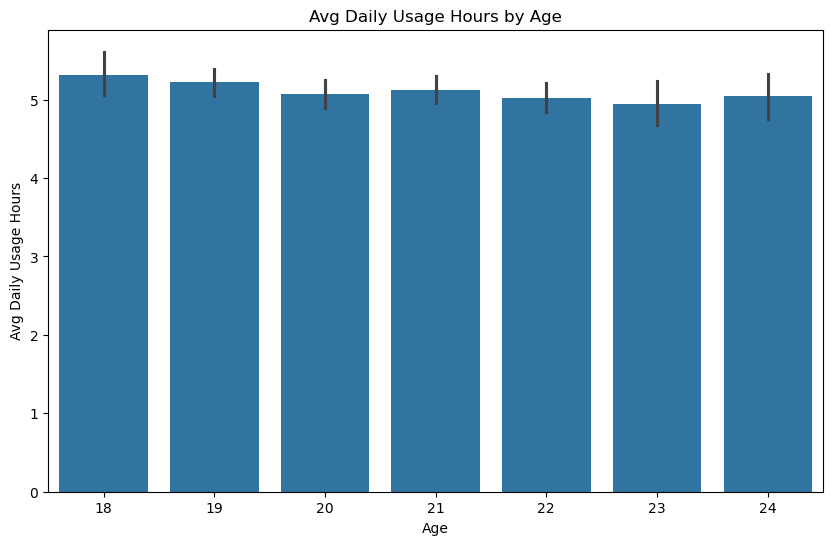

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Age', y='Avg_Daily_Usage_Hours', data=df)
plt.title('Avg Daily Usage Hours by Age')
plt.xlabel('Age')
plt.ylabel('Avg Daily Usage Hours')
plt.show()

Section 6: Correlation & Pattern Analysis

24. What is the correlation between:

· Usage hours & mental health

· Usage hours & sleep

· Sleep & mental health

25. Which variables show strong correlations?

26. Are there any unexpected patterns or anomalies?

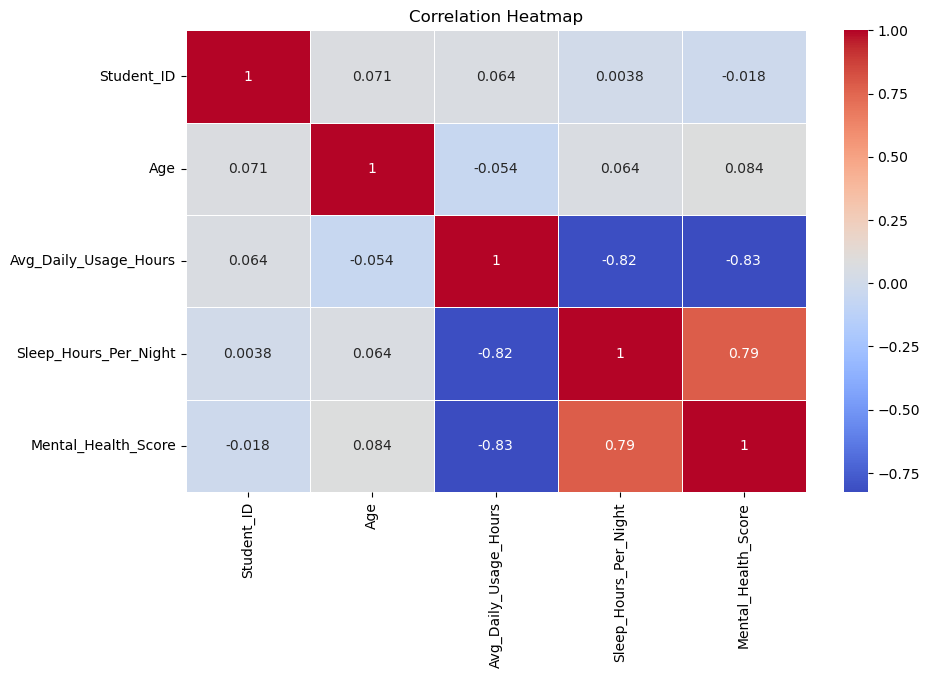

In [36]:
## correlation 
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')    
plt.show()